# Задание 1. Пропущенные значения и корреляции



- генерируется воспроизводимая выборка из 1000 объектов;
- исследуется, как случайные (MCAR) и зависимые от значения (MNAR) пропуски меняют корреляции;
- сравниваются медианная, kNN-, регрессионная и MICE-импутации;
- строятся raincloud, pair plot, heatmap, scatter-панели и UpSet-представления.


## 0. Импорт и параметры

Класс — один категориальный столбец `Class` с тремя значениями. Метки классов распределены независимо от признаков, поэтому заданная структура корреляций сохраняется и внутри классов с обычной выборочной погрешностью.

In [1]:
from itertools import combinations, product
from math import ceil
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"A NumPy version .* is required for this version of SciPy.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from IPython.display import display

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LinearRegression

warnings.filterwarnings("ignore", category=ConvergenceWarning)

FEATURES = ["A", "B", "C", "D"]
TARGET = "Class"

SEED = 2718
N_OBJECTS = 1000
N_CLASSES = 3
MISSING_PERCENTS = (0, 1, 2, 5, 10, 20, 50, 80)
SELECTED_PERCENT = 20
PAIR_1 = ("A", "B")
PAIR_2 = ("C", "D")
KNN_NEIGHBORS = 7

STYLE = {
    "palette": ["#3B82F6", "#F97316", "#10B981"],
    "markers": ["o", "s", "^"],
    "axis_color": "#334155",
    "axis_width": 0.9,
    "major_ticks": 5,
    "minor_divisions": 2,
    "grid": True,
    "square_axes": True,
    "font_family": "DejaVu Sans",
    "font_size": 9,
    "title_size": 12,
    "label_size": 10,
    "show_titles": True,
    "show_legend": True,
    "alpha": 0.48,
    "point_size": 16,
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": STYLE["font_family"],
    "font.size": STYLE["font_size"],
    "axes.titlesize": STYLE["title_size"],
    "axes.labelsize": STYLE["label_size"],
    "figure.dpi": 95,
    "savefig.dpi": 150,
})

In [2]:
def decorate_axis(ax, square=None):
    """Единая настройка осей; значения меняются в STYLE."""
    for spine in ax.spines.values():
        spine.set_color(STYLE["axis_color"])
        spine.set_linewidth(STYLE["axis_width"])
    ax.tick_params(
        axis="both",
        which="both",
        color=STYLE["axis_color"],
        width=STYLE["axis_width"],
    )
    ax.xaxis.set_major_locator(MaxNLocator(STYLE["major_ticks"]))
    ax.yaxis.set_major_locator(MaxNLocator(STYLE["major_ticks"]))
    if STYLE["minor_divisions"] > 0:
        ax.xaxis.set_minor_locator(AutoMinorLocator(STYLE["minor_divisions"]))
        ax.yaxis.set_minor_locator(AutoMinorLocator(STYLE["minor_divisions"]))
    ax.grid(STYLE["grid"], which="major", alpha=0.25)
    ax.grid(STYLE["grid"], which="minor", alpha=0.08)
    make_square = STYLE["square_axes"] if square is None else square
    if make_square:
        ax.set_box_aspect(1)


def class_slices(frame):
    yield "all", frame
    for label in sorted(frame[TARGET].dropna().unique()):
        yield str(label), frame.loc[frame[TARGET] == label]

## 1.1. Генерация исходного датасета

Теоретическая ковариационная матрица имеет единичные дисперсии, `cov(A, B)=0.9` и нулевые остальные внедиагональные элементы.

In [3]:
def generate_sample(n=N_OBJECTS, n_classes=N_CLASSES, seed=SEED):
    covariance = np.eye(len(FEATURES))
    covariance[0, 1] = covariance[1, 0] = 0.9

    rng = np.random.default_rng(seed)
    values = rng.multivariate_normal(
        mean=np.zeros(len(FEATURES)),
        cov=covariance,
        size=n,
        check_valid="raise",
    )

    labels = np.resize(np.arange(1, n_classes + 1), n)
    rng.shuffle(labels)  # класс не зависит от значений признаков

    frame = pd.DataFrame(values, columns=FEATURES)
    frame[TARGET] = pd.Categorical([f"class_{label}" for label in labels])
    return frame, covariance


dfS00, theoretical_covariance = generate_sample()

display(pd.DataFrame(
    theoretical_covariance,
    index=FEATURES,
    columns=FEATURES,
).style.set_caption("Заданная ковариационная матрица"))

display(dfS00.head())
print("Размер dfS00:", dfS00.shape)
print("Выборочная corr(A, B):", round(dfS00["A"].corr(dfS00["B"]), 4))

,A,B,C,D
A,1.000000,0.900000,0.000000,0.000000
B,0.900000,1.000000,0.000000,0.000000
C,0.000000,0.000000,1.000000,0.000000
D,0.000000,0.000000,0.000000,1.000000


,A,B,C,D,Class
0,-0.419101,-0.205539,-2.204669,-0.052008,class_3
1,-0.086712,-0.320844,-0.060253,0.441516,class_3
2,1.109225,0.828343,-0.145220,-2.414626,class_1
3,-2.049365,-1.644757,1.076598,-0.149720,class_2
4,1.329138,1.391846,0.543709,-0.819328,class_3


Размер dfS00: (1000, 5)
Выборочная corr(A, B): 0.902


## 1.2. Табличная статистика

Отдельно выводятся паспорт выборки, типы столбцов, статистики количественных признаков и сводка по классам.

In [4]:
def dataset_tables(frame):
    numeric = frame[FEATURES]

    passport = pd.DataFrame({
        "Показатель": [
            "Число объектов",
            "Число количественных признаков",
            "Всего столбцов",
            "Число классов",
            "Строк с NaN",
            "Строк хотя бы с одним точным нулём",
        ],
        "Значение": [
            len(frame),
            len(FEATURES),
            frame.shape[1],
            frame[TARGET].nunique(),
            int(numeric.isna().any(axis=1).sum()),
            int(numeric.eq(0).any(axis=1).sum()),
        ],
    })

    types = pd.DataFrame({
        "Столбец": frame.columns,
        "Тип": frame.dtypes.astype(str).values,
        "Уникальных значений": [frame[col].nunique(dropna=True) for col in frame],
    })

    by_class = []
    for label, part in frame.groupby(TARGET, observed=True):
        values = part[FEATURES]
        by_class.append({
            "Класс": label,
            "Объектов": len(part),
            "Строк с NaN": int(values.isna().any(axis=1).sum()),
            "Строк с нулём": int(values.eq(0).any(axis=1).sum()),
        })

    descriptive = numeric.describe(percentiles=[0.25, 0.5, 0.75]).T
    descriptive["IQR"] = descriptive["75%"] - descriptive["25%"]
    descriptive["Range"] = descriptive["max"] - descriptive["min"]
    descriptive["skew"] = numeric.skew()
    descriptive["kurtosis"] = numeric.kurtosis()
    descriptive["NaN"] = numeric.isna().sum()
    descriptive["zeros"] = numeric.eq(0).sum()

    return passport, types, descriptive, pd.DataFrame(by_class)


passport, types, descriptive, class_summary = dataset_tables(dfS00)
display(passport.style.hide(axis="index").set_caption("Паспорт датасета"))
display(types.style.hide(axis="index").set_caption("Типы столбцов"))
display(class_summary.style.hide(axis="index").set_caption("Статистика по классам"))
display(descriptive.round(3).style.set_caption("Описательные статистики признаков"))

Показатель,Значение
Число объектов,1000
Число количественных признаков,4
Всего столбцов,5
Число классов,3
Строк с NaN,0
Строк хотя бы с одним точным нулём,0


Столбец,Тип,Уникальных значений
A,float64,1000
B,float64,1000
C,float64,1000
D,float64,1000
Class,category,3


Класс,Объектов,Строк с NaN,Строк с нулём
class_1,334,0,0
class_2,333,0,0
class_3,333,0,0


,count,mean,std,min,25%,50%,75%,max,IQR,Range,skew,kurtosis,NaN,zeros
A,1000.000000,-0.003000,1.015000,-3.670000,-0.699000,-0.024000,0.691000,3.669000,1.391000,7.338000,0.085000,0.101000,0,0
B,1000.000000,-0.004000,1.003000,-3.596000,-0.694000,-0.026000,0.676000,3.375000,1.370000,6.971000,0.081000,0.045000,0,0
C,1000.000000,0.045000,1.023000,-3.013000,-0.638000,-0.014000,0.747000,3.492000,1.386000,6.505000,0.091000,-0.117000,0,0
D,1000.000000,-0.030000,1.042000,-3.064000,-0.737000,-0.049000,0.658000,2.762000,1.395000,5.826000,-0.008000,-0.109000,0,0


## 1.3. Raincloud-графики

Для каждого класса «облако» показывает KDE, boxplot — медиану, IQR и полный размах, а точки с джиттером — отдельные наблюдения. Параметр `whis=(0, 100)` можно заменить, например, на `whis=1.5`.

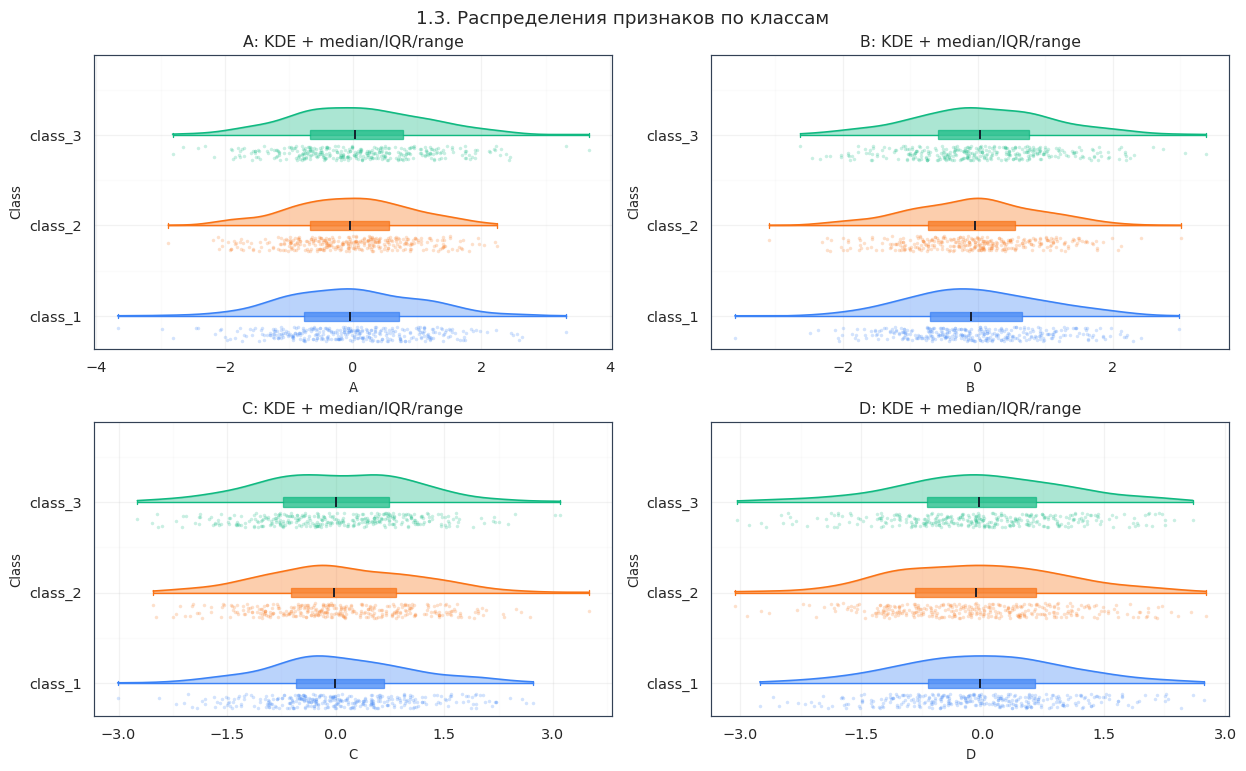

In [5]:
def raincloud_panel(frame, whis=(0, 100), seed=SEED):
    labels = list(frame[TARGET].cat.categories)
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

    for ax, feature in zip(axes.flat, FEATURES):
        for position, (label, color) in enumerate(zip(labels, STYLE["palette"])):
            values = frame.loc[frame[TARGET] == label, feature].dropna().to_numpy()
            grid = np.linspace(values.min(), values.max(), 220)
            density = gaussian_kde(values)(grid)
            density = 0.30 * density / density.max()

            # KDE только над центральной линией — «облако».
            ax.fill_between(grid, position, position + density, color=color, alpha=0.35)
            ax.plot(grid, position + density, color=color, lw=1.2)

            # Boxplot на центральной линии.
            box = ax.boxplot(
                [values], positions=[position], vert=False, widths=0.10,
                patch_artist=True, showfliers=False, whis=whis, manage_ticks=False,
                medianprops={"color": "#111827", "linewidth": 1.4},
                whiskerprops={"color": color}, capprops={"color": color},
            )
            box["boxes"][0].set(facecolor=color, alpha=0.72, edgecolor=color)

            # «Дождь» ниже линии.
            y = position - 0.12 - rng.uniform(0, 0.16, len(values))
            ax.scatter(values, y, s=7, color=color, alpha=0.22, linewidths=0)

        ax.set_xlabel(feature)
        ax.set_ylabel(TARGET)
        ax.set_ylim(-0.36, len(labels) - 0.5 + 0.38)
        if STYLE["show_titles"]:
            ax.set_title(f"{feature}: KDE + median/IQR/range")
        decorate_axis(ax, square=False)
        ax.set_yticks(range(len(labels)), labels)

    fig.suptitle("1.3. Распределения признаков по классам", fontsize=14)
    plt.show()


raincloud_panel(dfS00)

## 1.4. Все пары признаков

Ниже не используется готовый `pairplot`: матрица строится явно, чтобы параметры осей, рисок, сетки, шрифтов, прозрачности, легенды и заголовка управлялись словарём `STYLE`.

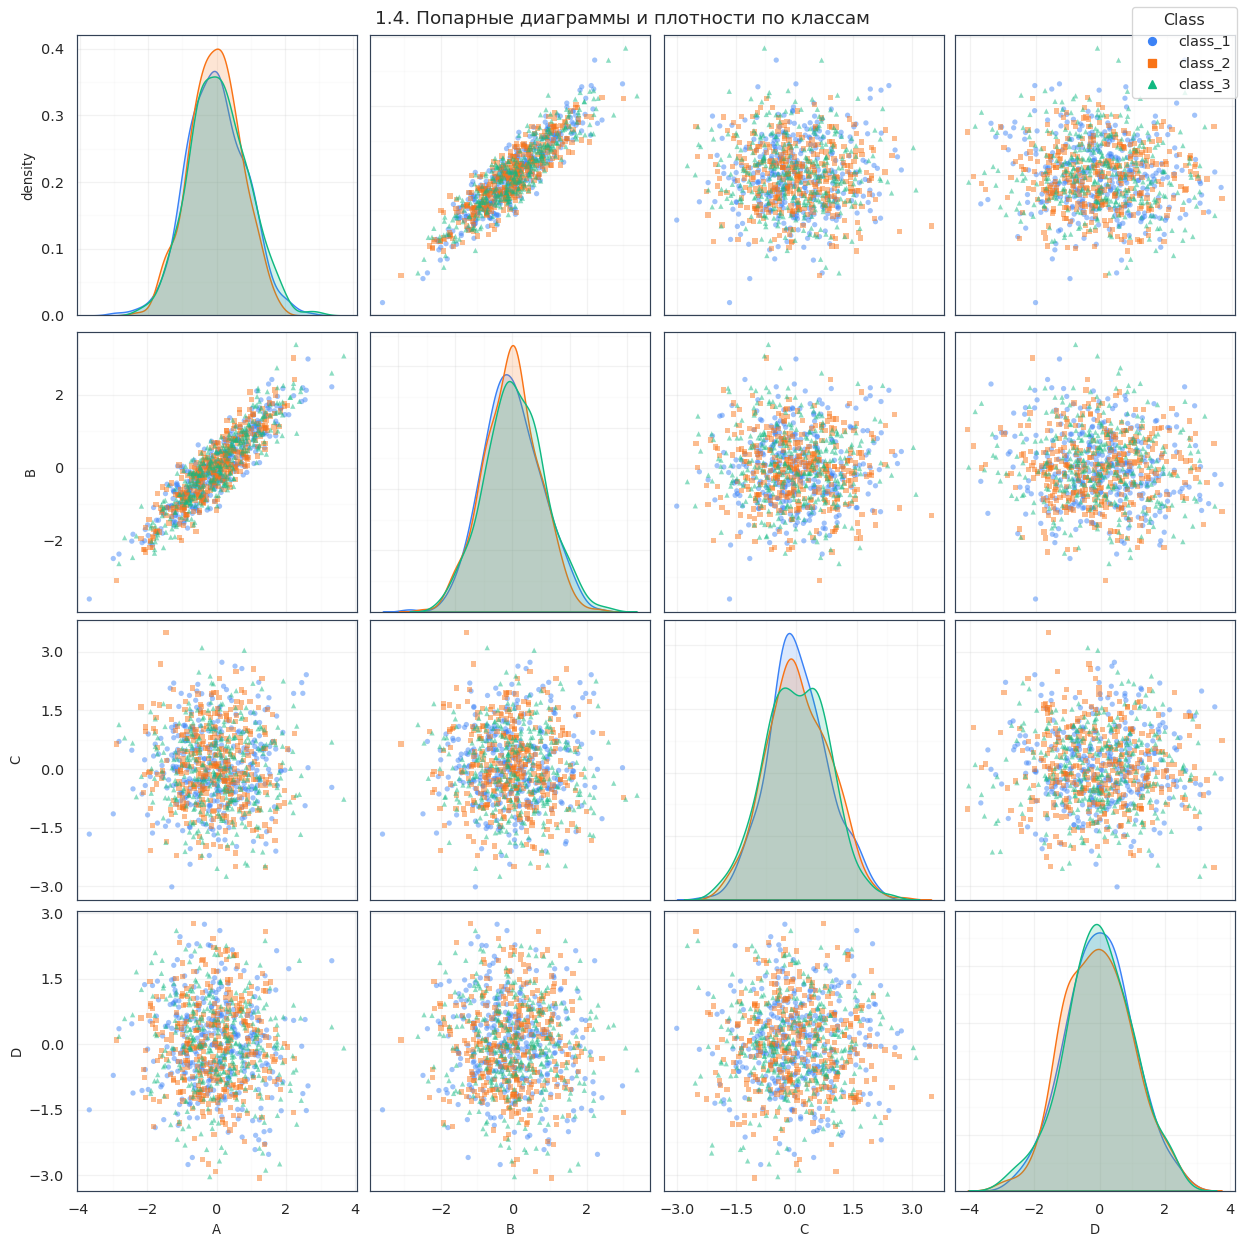

In [6]:
def pair_matrix(frame):
    labels = list(frame[TARGET].cat.categories)
    n = len(FEATURES)
    fig, axes = plt.subplots(n, n, figsize=(13, 13), constrained_layout=True)

    for row, y_name in enumerate(FEATURES):
        for col, x_name in enumerate(FEATURES):
            ax = axes[row, col]
            for label, color, marker in zip(
                labels, STYLE["palette"], STYLE["markers"]
            ):
                part = frame.loc[frame[TARGET] == label]
                if row == col:
                    sns.kdeplot(
                        data=part, x=x_name, ax=ax, color=color,
                        fill=True, alpha=0.18, linewidth=1.1,
                    )
                else:
                    ax.scatter(
                        part[x_name], part[y_name],
                        color=color, marker=marker,
                        s=STYLE["point_size"], alpha=STYLE["alpha"],
                        edgecolors="none",
                    )

            if row == n - 1:
                ax.set_xlabel(x_name)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)
            if col == 0:
                ax.set_ylabel("density" if row == col else y_name)
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)
            decorate_axis(ax)

    if STYLE["show_titles"]:
        fig.suptitle("1.4. Попарные диаграммы и плотности по классам", fontsize=14)
    if STYLE["show_legend"]:
        handles = [
            Line2D([], [], linestyle="", marker=marker, color=color, label=label)
            for label, color, marker in zip(
                labels, STYLE["palette"], STYLE["markers"]
            )
        ]
        fig.legend(handles=handles, title=TARGET, loc="upper right")
    plt.show()


pair_matrix(dfS00)

## 1.5. Корреляции Пирсона и Спирмана

Коэффициент корреляции Пирсона измеряет силу линейной связи между признаками $X$ и $Y$:

$$
r_{XY} = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}.
$$

Здесь $x_i$ и $y_i$ — значения двух признаков у объекта $i$, $\bar{x}$ и $\bar{y}$ — их выборочные средние, $n$ — число объектов.

Коэффициент Спирмена — это корреляция Пирсона между рангами исходных значений:

$$
\rho_s = \operatorname{corr}(R_X, R_Y).
$$

Если совпадающих рангов нет, используется эквивалентная формула:

$$
\rho_s = 1 - \frac{6\sum_{i=1}^{n} d_i^2}{n(n^2-1)},
$$

где $d_i = R(x_i)-R(y_i)$ — разность рангов объекта $i$. Пирсон оценивает линейную связь, а Спирмен — монотонную связь.

Столбцы панно соответствуют всей выборке и отдельным классам; строки — двум коэффициентам корреляции.

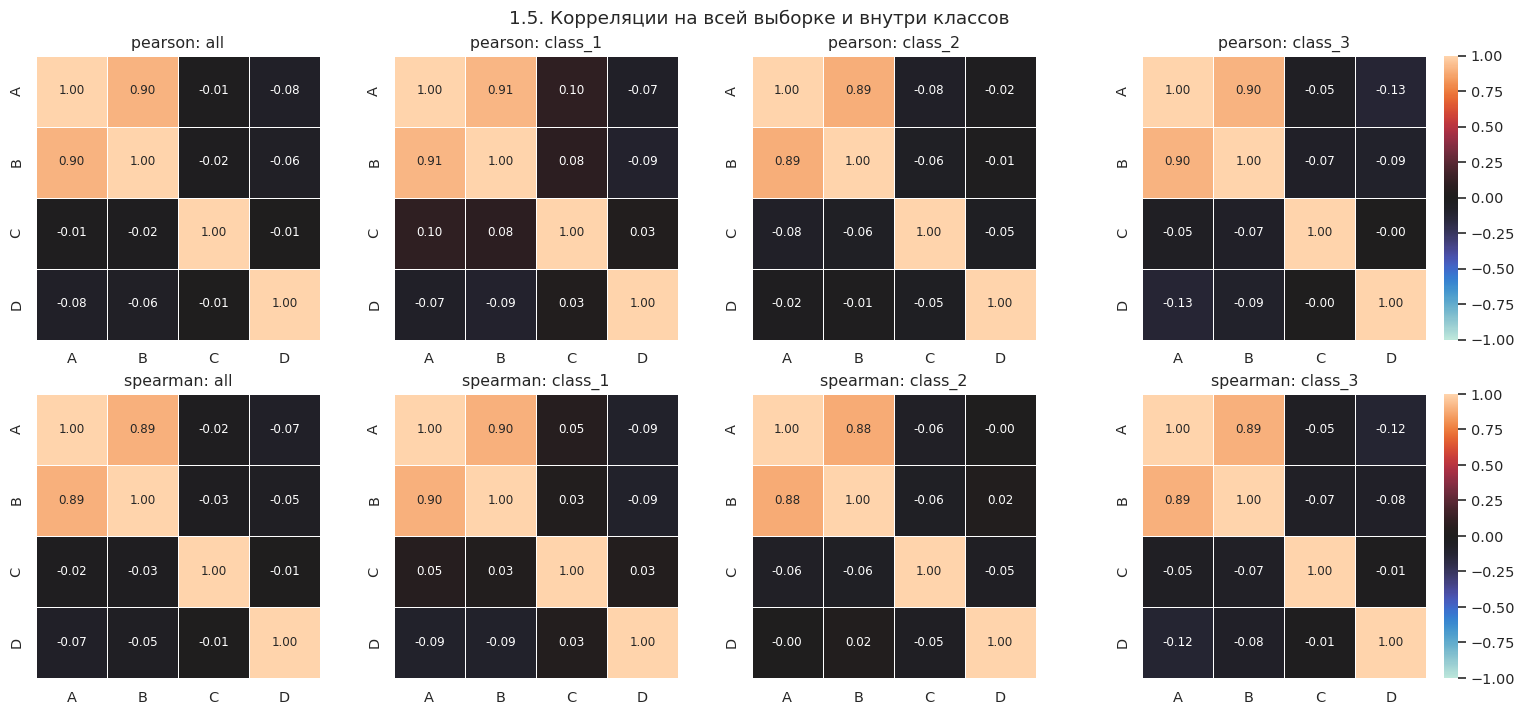

In [7]:
def correlation_grid(frame, methods=("pearson", "spearman"), title="Корреляции"):
    groups = list(class_slices(frame))
    fig, axes = plt.subplots(
        len(methods), len(groups),
        figsize=(4.0 * len(groups), 3.7 * len(methods)),
        squeeze=False, constrained_layout=True,
    )

    for row, method in enumerate(methods):
        for col, (group_name, part) in enumerate(groups):
            sns.heatmap(
                part[FEATURES].corr(method=method),
                vmin=-1, vmax=1, center=0, cmap="icefire",
                annot=True, fmt=".2f", square=True,
                linewidths=0.5, cbar=(col == len(groups) - 1),
                ax=axes[row, col],
            )
            axes[row, col].set_title(f"{method}: {group_name}")

    fig.suptitle(title, fontsize=14)
    plt.show()


correlation_grid(dfS00, title="1.5. Корреляции на всей выборке и внутри классов")

## 1.6. Случайное удаление ячеек (MCAR)

Удаляется ровно заданный процент ячеек только среди четырёх количественных признаков. Столбец класса не изменяется.

dataset,missing_cells,missing_percent,rows_with_missing
dfSd00,0,0.000000,0
dfSd01,40,1.000000,40
dfSd02,80,2.000000,78
dfSd05,200,5.000000,181
dfSd10,400,10.000000,344
dfSd20,800,20.000000,587
dfSd50,2000,50.000000,926
dfSd80,3200,80.000000,997


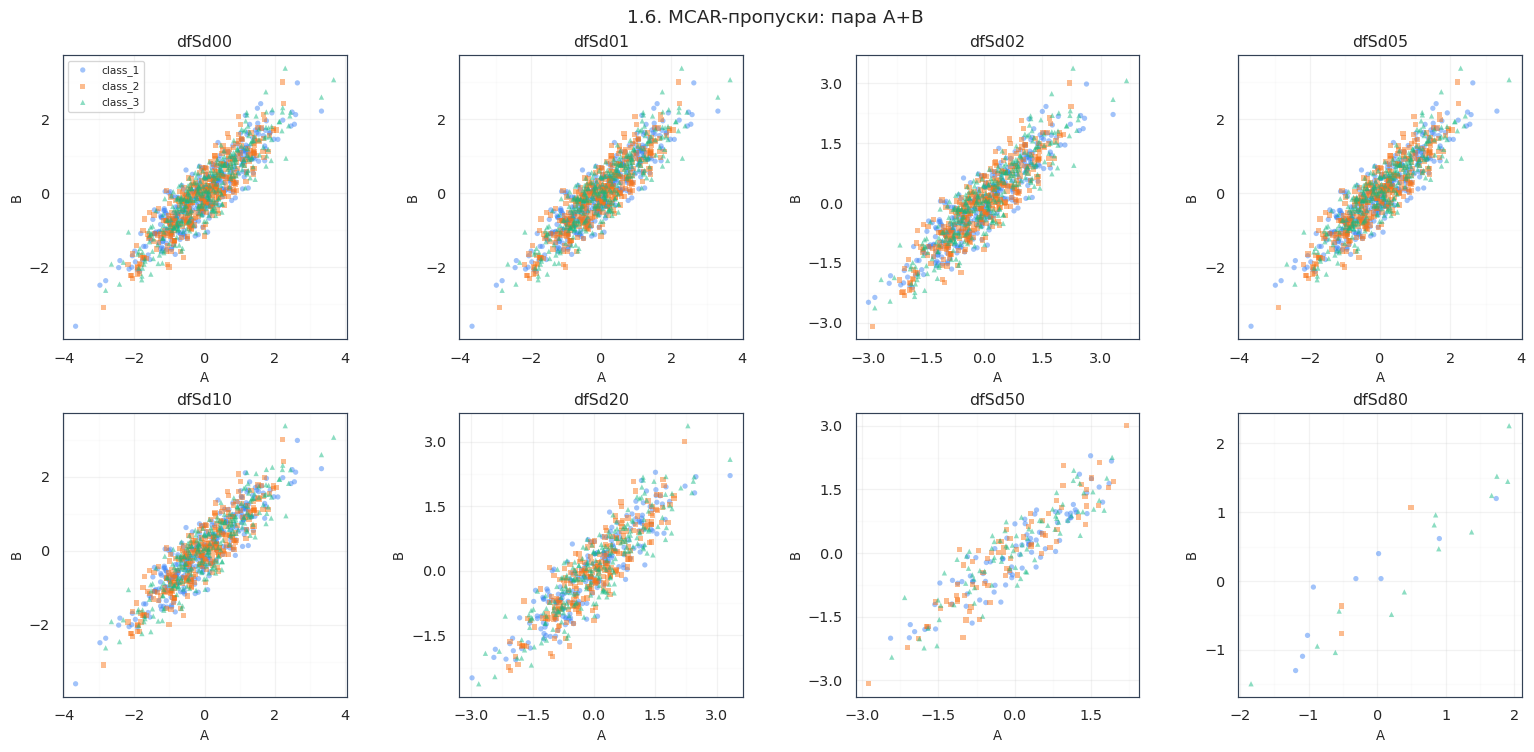

In [8]:
def make_mcar(frame, percent, seed):
    if not 0 <= percent <= 100:
        raise ValueError("Процент должен находиться в диапазоне [0, 100].")

    result = frame.copy(deep=True)
    values = result[FEATURES].to_numpy(copy=True)
    rng = np.random.default_rng(seed)
    count = round(values.size * percent / 100)
    chosen = rng.choice(values.size, size=count, replace=False)
    rows, columns = np.unravel_index(chosen, values.shape)
    values[rows, columns] = np.nan
    result.loc[:, FEATURES] = values
    return result


def scatter_panel(datasets, pair, title, ncols=4):
    nrows = ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.1 * ncols, 3.9 * nrows),
        squeeze=False, constrained_layout=True,
    )

    for ax, (name, frame) in zip(axes.flat, datasets.items()):
        for label, color, marker in zip(
            frame[TARGET].cat.categories, STYLE["palette"], STYLE["markers"]
        ):
            part = frame.loc[frame[TARGET] == label]
            ax.scatter(
                part[pair[0]], part[pair[1]], label=label,
                color=color, marker=marker, s=STYLE["point_size"],
                alpha=STYLE["alpha"], edgecolors="none",
            )
        ax.set(xlabel=pair[0], ylabel=pair[1], title=name)
        decorate_axis(ax)

    for ax in axes.flat[len(datasets):]:
        ax.set_visible(False)

    if STYLE["show_legend"]:
        axes.flat[0].legend(fontsize=8)
    fig.suptitle(title, fontsize=14)
    plt.show()


missing_sets = {
    f"dfSd{percent:02d}": make_mcar(dfS00, percent, SEED + 100 + percent)
    for percent in MISSING_PERCENTS
}

missing_summary = pd.DataFrame([
    {
        "dataset": name,
        "missing_cells": int(frame[FEATURES].isna().sum().sum()),
        "missing_percent": 100 * frame[FEATURES].isna().sum().sum()
        / (len(frame) * len(FEATURES)),
        "rows_with_missing": int(frame[FEATURES].isna().any(axis=1).sum()),
    }
    for name, frame in missing_sets.items()
])
display(missing_summary.round(2).style.hide(axis="index"))
scatter_panel(missing_sets, PAIR_1, "1.6. MCAR-пропуски: пара A+B")

## 1.7. Заполнение медианой

Для каждого уровня MCAR создаётся отдельный датасет. Корреляции показываются для всей выборки и для каждого класса.

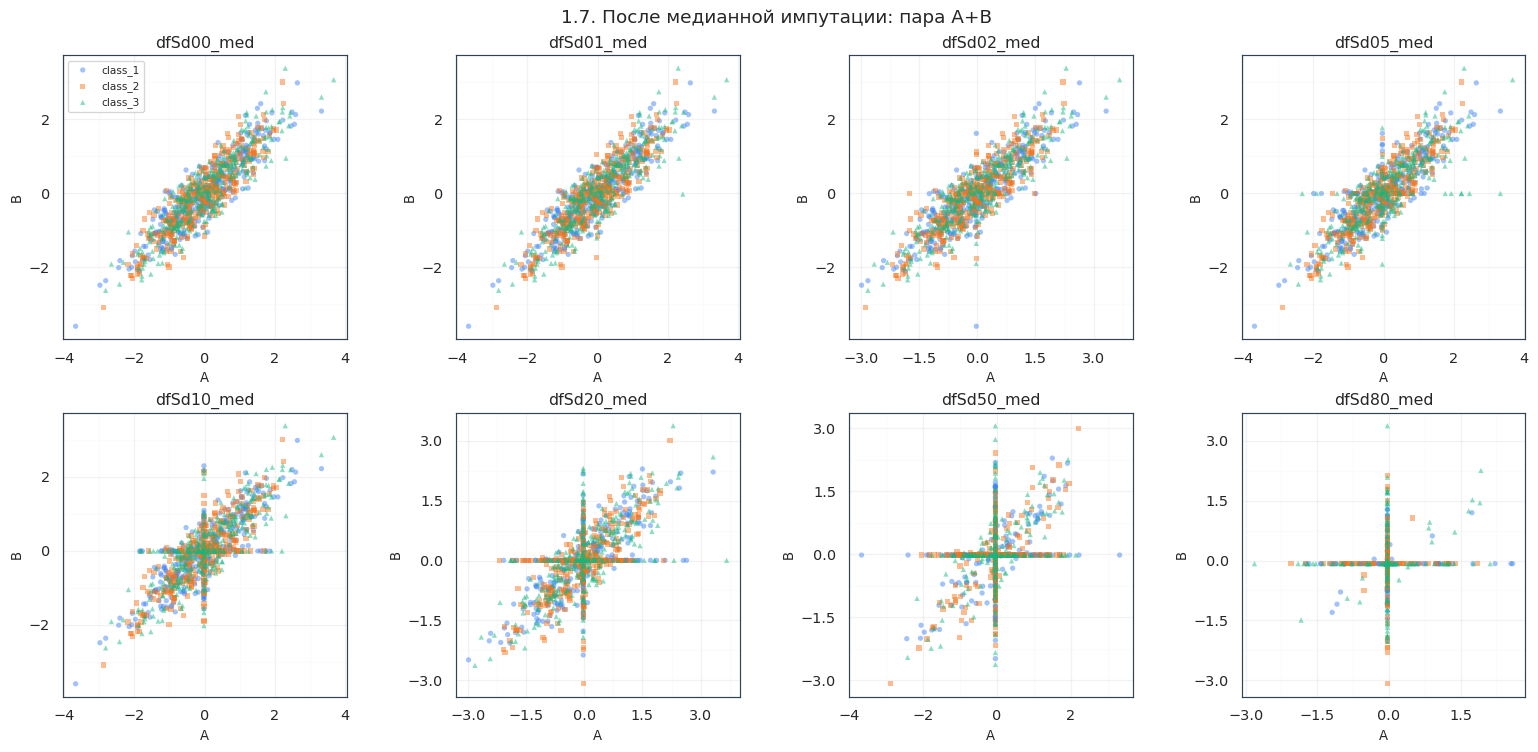

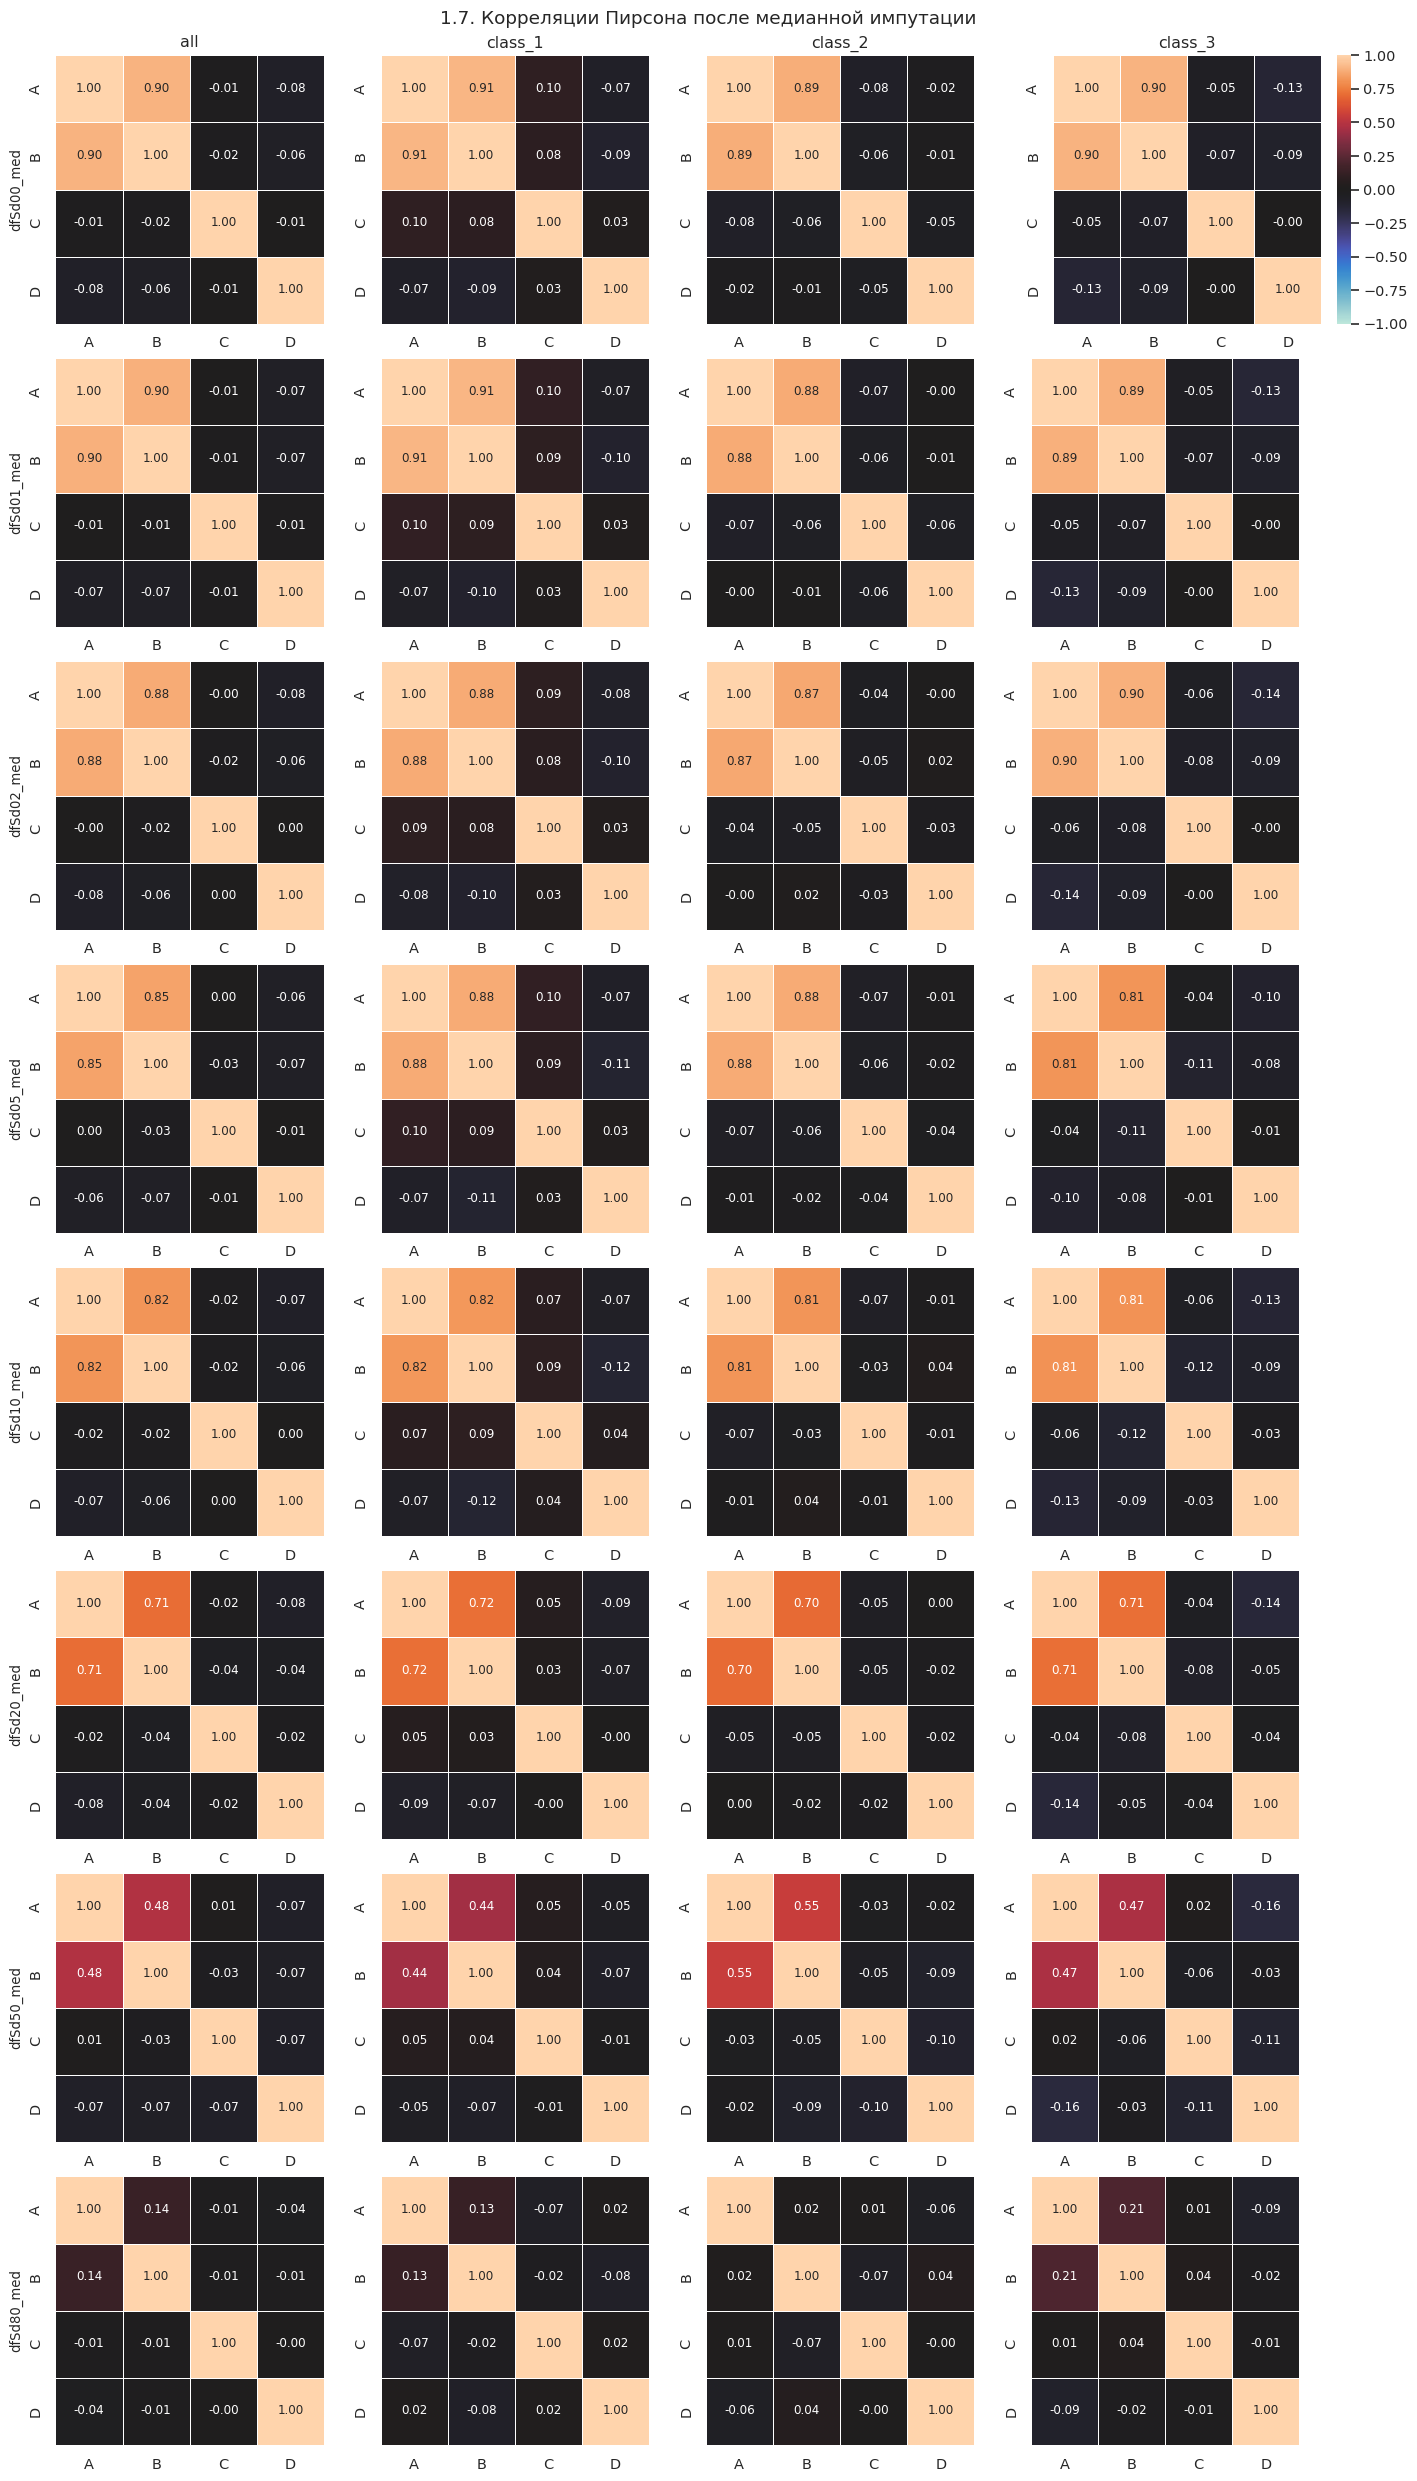

In [9]:
def impute_columns(frame, estimator):
    result = frame.copy(deep=True)
    result.loc[:, FEATURES] = estimator.fit_transform(result[FEATURES])
    return result


median_sets = {
    name + "_med": impute_columns(frame, SimpleImputer(strategy="median"))
    for name, frame in missing_sets.items()
}

scatter_panel(median_sets, PAIR_1, "1.7. После медианной импутации: пара A+B")


def correlation_atlas(datasets, method="pearson", title="Корреляции"):
    first = next(iter(datasets.values()))
    group_names = ["all", *map(str, first[TARGET].cat.categories)]
    fig, axes = plt.subplots(
        len(datasets), len(group_names),
        figsize=(3.7 * len(group_names), 3.25 * len(datasets)),
        squeeze=False, constrained_layout=True,
    )

    for row, (dataset_name, frame) in enumerate(datasets.items()):
        for col, (group_name, part) in enumerate(class_slices(frame)):
            sns.heatmap(
                part[FEATURES].corr(method=method),
                vmin=-1, vmax=1, center=0, cmap="icefire",
                annot=True, fmt=".2f", square=True, linewidths=0.4,
                cbar=(row == 0 and col == len(group_names) - 1),
                ax=axes[row, col],
            )
            axes[row, col].set_title(group_name if row == 0 else "")
            axes[row, col].set_ylabel(dataset_name if col == 0 else "")

    fig.suptitle(title, fontsize=14)
    plt.show()


correlation_atlas(
    median_sets,
    method="pearson",
    title="1.7. Корреляции Пирсона после медианной импутации",
)

## 1.8. Сравнение четырёх способов импутации

Для выбранного `dfSd20` используются:

1. медиана;
2. k ближайших соседей;
3. итеративные линейные регрессии;
4. MICE с Bayesian Ridge и выборкой из предсказательного распределения.

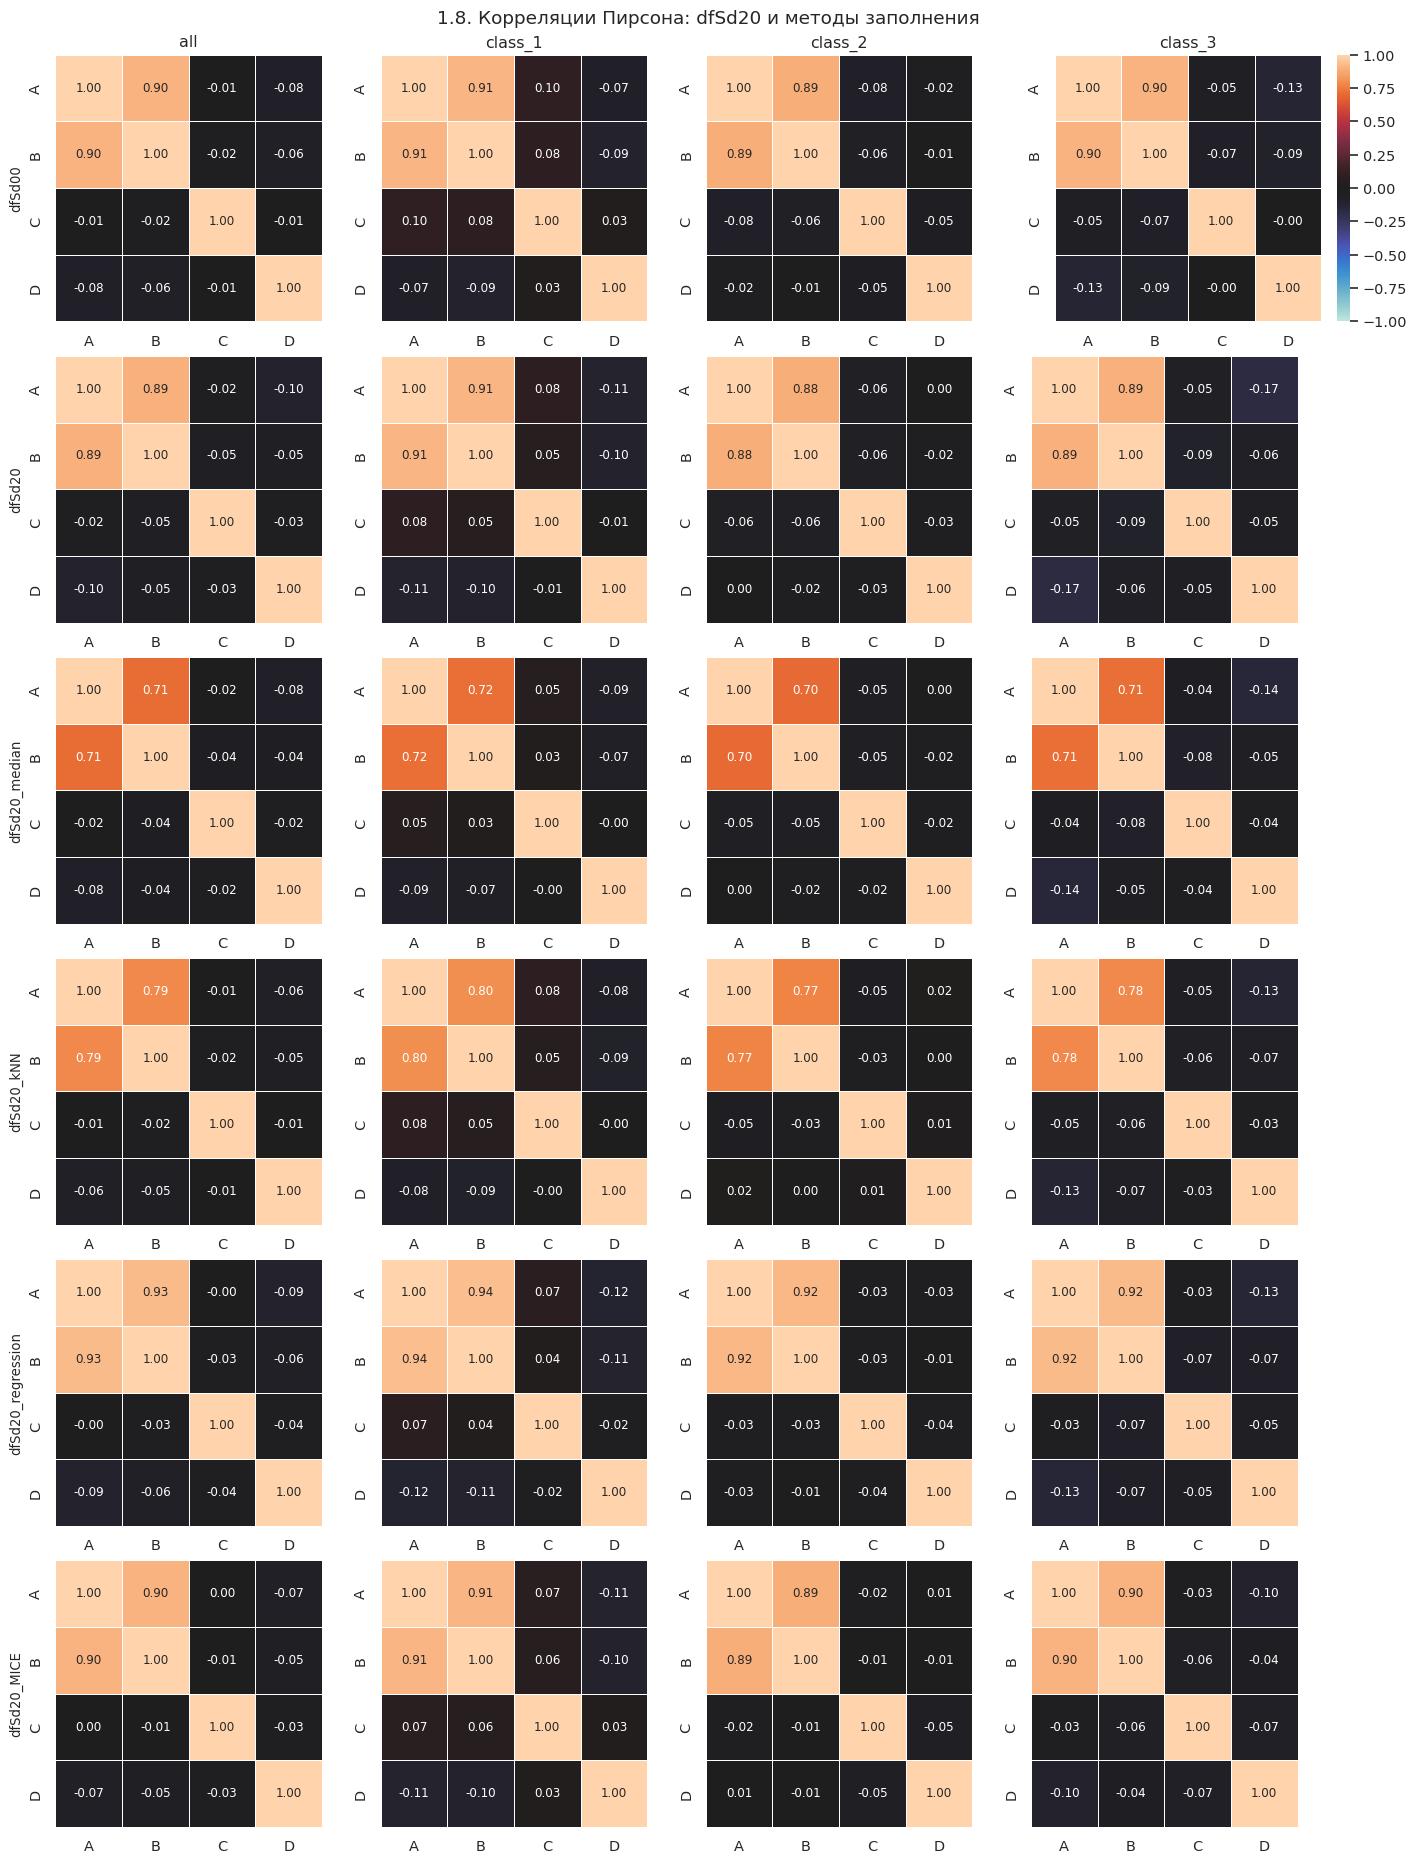

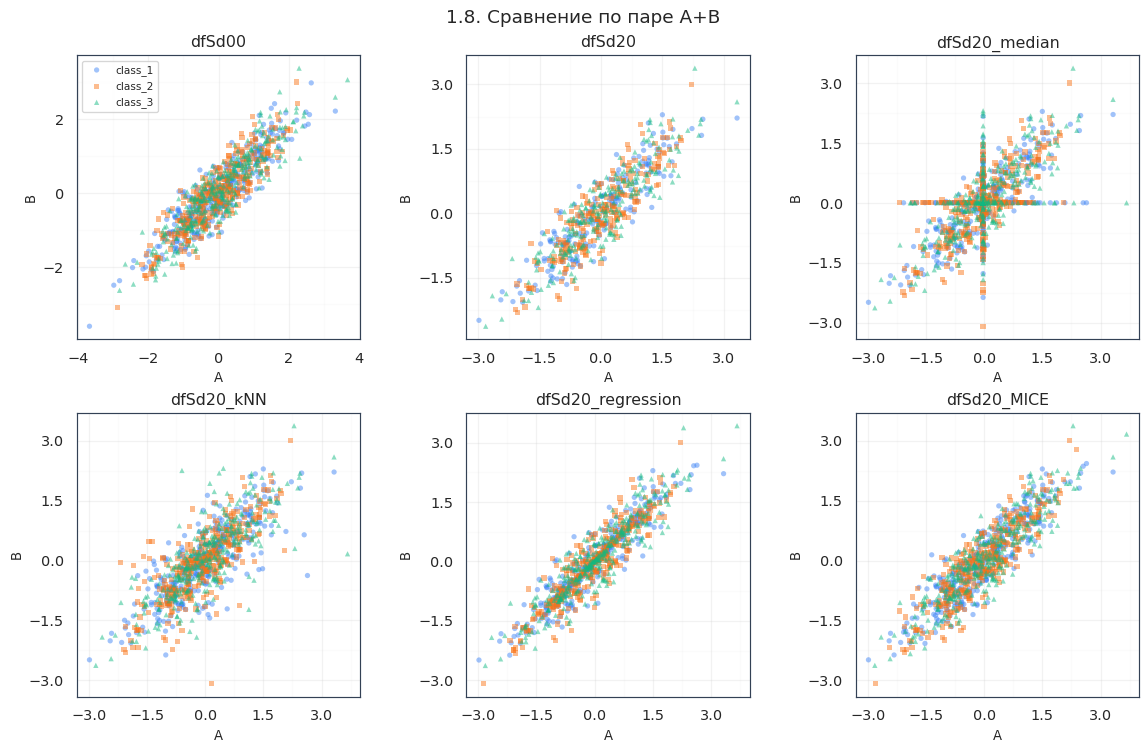

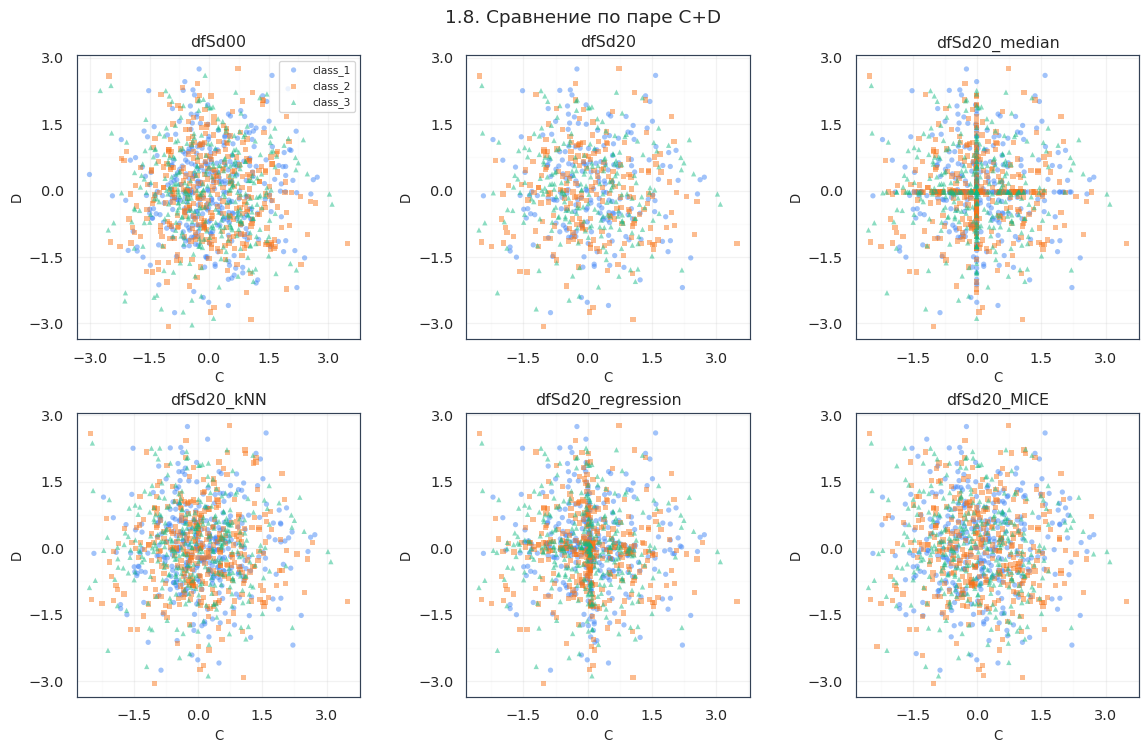

In [10]:
def build_imputations(frame, seed=SEED):
    methods = {
        "median": SimpleImputer(strategy="median"),
        "kNN": KNNImputer(n_neighbors=KNN_NEIGHBORS, weights="distance"),
        "regression": IterativeImputer(
            estimator=LinearRegression(),
            initial_strategy="median",
            max_iter=15,
            imputation_order="roman",
            sample_posterior=False,
            random_state=seed,
        ),
        "MICE": IterativeImputer(
            estimator=BayesianRidge(),
            initial_strategy="median",
            max_iter=15,
            imputation_order="random",
            sample_posterior=True,
            random_state=seed,
        ),
    }
    return {
        name: impute_columns(frame, estimator)
        for name, estimator in methods.items()
    }


selected_name = f"dfSd{SELECTED_PERCENT:02d}"
selected_missing = missing_sets[selected_name]
imputed = build_imputations(selected_missing)

comparison = {
    "dfSd00": dfS00,
    selected_name: selected_missing,
    **{f"{selected_name}_{name}": frame for name, frame in imputed.items()},
}

correlation_atlas(
    comparison,
    method="pearson",
    title=f"1.8. Корреляции Пирсона: {selected_name} и методы заполнения",
)
scatter_panel(comparison, PAIR_1, "1.8. Сравнение по паре A+B", ncols=3)
scatter_panel(comparison, PAIR_2, "1.8. Сравнение по паре C+D", ncols=3)

## 1.9. UpSet-представления

Для пропусков считается число строк с **точно таким** сочетанием отсутствующих признаков.

Для совпадающих значений рассматривается каждый непустой набор признаков. Значение столбца — число строк, участвующих в дубликатах по выбранному набору. Например, для набора `{A, B}` две строки считаются совпадающими, если у них одновременно равны и `A`, и `B`.

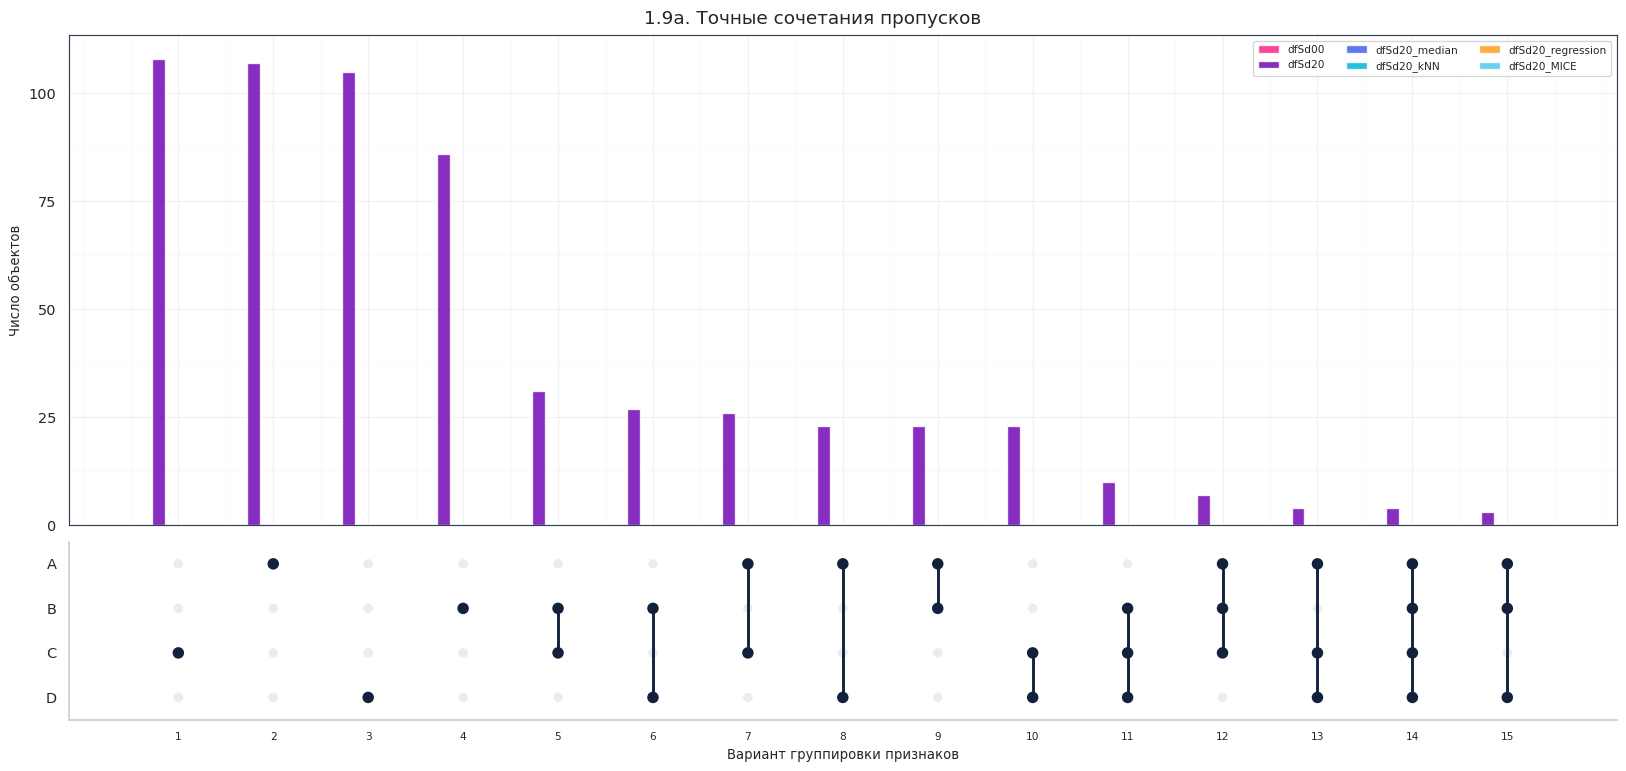

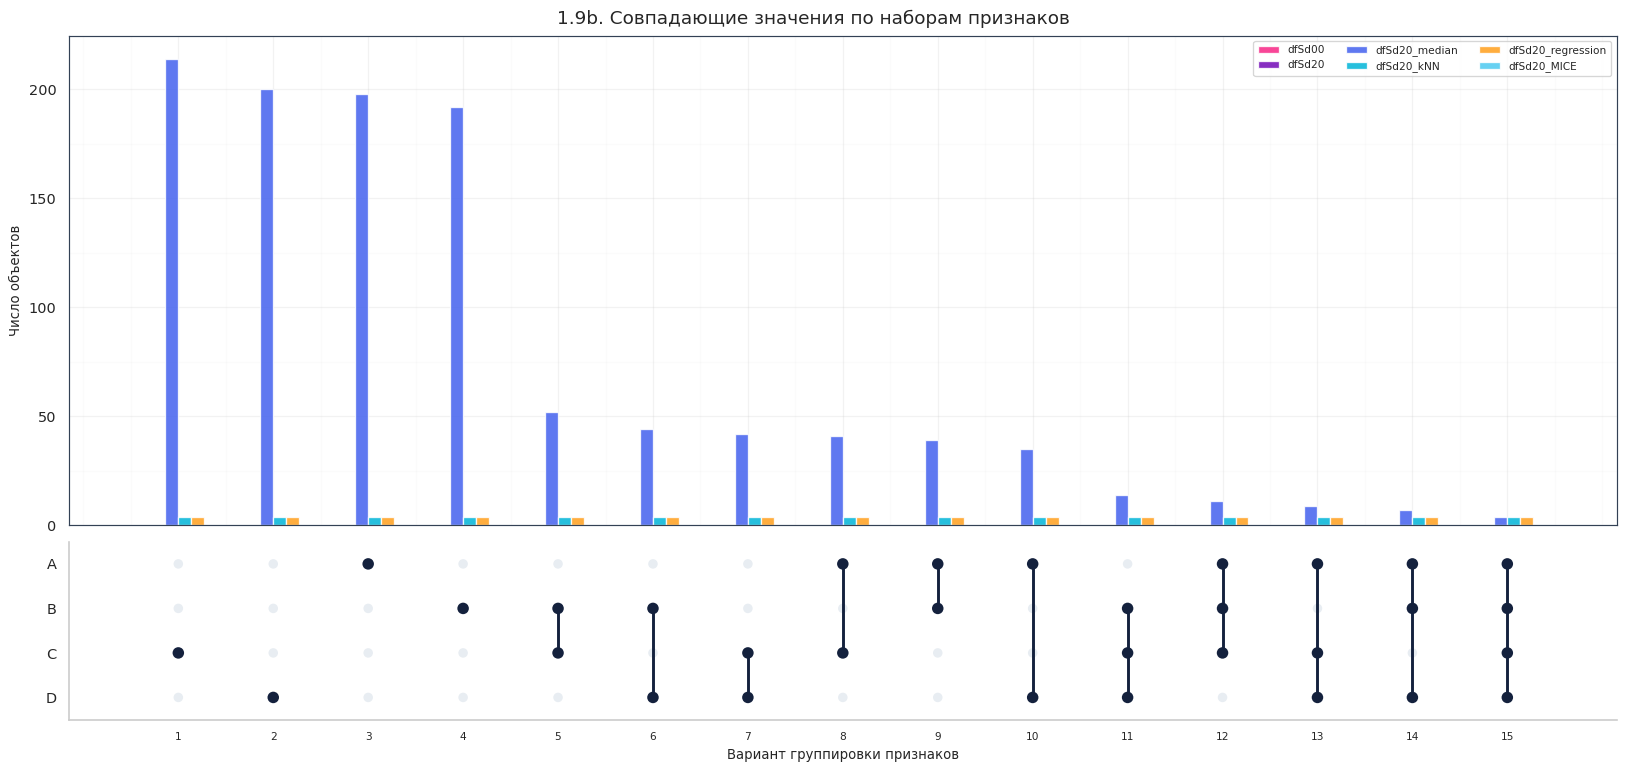

False True  False                   True              False  \
                  False False False True              False       True  False   
                  True  False False False True  False True  False False True    
                  False False True  False False True  False True  False True    
dfSd00                0     0     0     0     0     0     0     0     0     0   
dfSd20              108   107   105    86    31    27    26    23    23    23   
dfSd20_median         0     0     0     0     0     0     0     0     0     0   
dfSd20_kNN            0     0     0     0     0     0     0     0     0     0   
dfSd20_regression     0     0     0     0     0     0     0     0     0     0   
dfSd20_MICE           0     0     0     0     0     0     0     0     0     0   

                        True                     
                  True  True  False True         
                  True  True  True  True  False  
                  True  False True  True  True   
dfSd00                0     0     0     0     0  
dfSd20               10     7     4     4     3  
dfSd20_median         0     0     0     0     0  
dfSd20_kNN            0     0     0     0     0  
dfSd20_regression     0     0     0     0     0  
dfSd20_MICE           0     0     0     0     0

False       True  False                   True               \
                  False       False True              False False True  False   
                  True  False False False True  False True  True  False False   
                  False True  False False False True  True  False False True    
dfSd00                0     0     0     0     0     0     0     0     0     0   
dfSd20                0     0     0     0     0     0     0     0     0     0   
dfSd20_median       214   200   198   192    52    44    42    41    39    35   
dfSd20_kNN            4     4     4     4     4     4     4     4     4     4   
dfSd20_regression     4     4     4     4     4     4     4     4     4     4   
dfSd20_MICE           0     0     0     0     0     0     0     0     0     0   

                  False True                     
                  True  True  False True         
                  True  True  True  False True   
                  True  False True  True  True   
dfSd00                0     0     0     0     0  
dfSd20                0     0     0     0     0  
dfSd20_median        14    11     9     7     4  
dfSd20_kNN            4     4     4     4     4  
dfSd20_regression     4     4     4     4     4  
dfSd20_MICE           0     0     0     0     0

In [11]:
SUBSETS = [
    tuple(feature in subset for feature in FEATURES)
    for size in range(1, len(FEATURES) + 1)
    for subset in combinations(FEATURES, size)
]


def exact_missing_counts(frame):
    flags = frame[FEATURES].isna().to_numpy()
    return pd.Series({
        pattern: int(np.all(flags == np.array(pattern), axis=1).sum())
        for pattern in SUBSETS
    }, dtype=int)


def duplicate_subset_counts(frame):
    counts = {}
    for pattern in SUBSETS:
        cols = [feature for feature, active in zip(FEATURES, pattern) if active]
        complete = frame[cols].dropna()
        counts[pattern] = int(complete.duplicated(cols, keep=False).sum())
    return pd.Series(counts, dtype=int)


def upset_comparison(datasets, counter, title):
    count_table = pd.DataFrame({
        name: counter(frame) for name, frame in datasets.items()
    }).T
    ordered_patterns = count_table.sum(axis=0).sort_values(ascending=False).index
    count_table = count_table.loc[:, ordered_patterns]

    fig = plt.figure(figsize=(17, 8), constrained_layout=True)
    grid = fig.add_gridspec(2, 1, height_ratios=(3.3, 1.2))
    ax_bar = fig.add_subplot(grid[0])
    ax_matrix = fig.add_subplot(grid[1], sharex=ax_bar)

    x = np.arange(len(ordered_patterns))
    width = 0.82 / len(count_table)
    lab_colors = ["#F72585", "#7209B7", "#4361EE", "#00B4D8", "#FF9F1C", "#4CC9F0"]
    colors = [lab_colors[i % len(lab_colors)] for i in range(len(count_table))]

    for row, (name, values) in enumerate(count_table.iterrows()):
        offset = (row - (len(count_table) - 1) / 2) * width
        ax_bar.bar(
            x + offset, values.to_numpy(), width=width,
            label=name, color=colors[row], alpha=0.85,
        )

    ax_bar.set_ylabel("Число объектов")
    ax_bar.legend(ncol=3, fontsize=8)
    ax_bar.tick_params(labelbottom=False)
    decorate_axis(ax_bar, square=False)

    # Сначала рисуем все фоновые маркеры, затем соединения и только после
    # них активные маркеры. Поэтому светлые точки не перекрывают линии
    # и тёмные точки выбранных признаков.
    for col in range(len(ordered_patterns)):
        ax_matrix.scatter(
            [col] * len(FEATURES), range(len(FEATURES)),
            s=52, facecolor="#E8EDF2", edgecolor="none", zorder=1,
        )

    for col, pattern in enumerate(ordered_patterns):
        active_rows = [row for row, active in enumerate(pattern) if active]
        if len(active_rows) > 1:
            ax_matrix.plot(
                [col, col], [min(active_rows), max(active_rows)],
                color="#14213D", lw=2.2, zorder=2,
            )
        ax_matrix.scatter(
            [col] * len(active_rows), active_rows,
            s=76, facecolor="#14213D", edgecolor="none", zorder=3,
        )

    ax_matrix.set_yticks(range(len(FEATURES)), FEATURES)
    ax_matrix.set_ylim(len(FEATURES) - 0.5, -0.5)
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels(range(1, len(x) + 1), fontsize=8)
    ax_matrix.set_xlabel("Вариант группировки признаков")
    ax_matrix.grid(False)
    ax_matrix.spines[["top", "right"]].set_visible(False)
    fig.suptitle(title, fontsize=14)
    plt.show()

    return count_table


missing_upset_table = upset_comparison(
    comparison,
    exact_missing_counts,
    "1.9a. Точные сочетания пропусков",
)
duplicate_upset_table = upset_comparison(
    comparison,
    duplicate_subset_counts,
    "1.9b. Совпадающие значения по наборам признаков",
)

display(missing_upset_table)
display(duplicate_upset_table)

## 1.10. MNAR-пропуски

В `dfMNAR` удаляются значения `C` и `D`, которые меньше медианы соответствующего признака в исходной выборке. Это уже не случайный механизм: вероятность пропуска непосредственно зависит от скрываемого значения.

,median_threshold,missing_after_MNAR
C,-0.0142,500
D,-0.0487,500


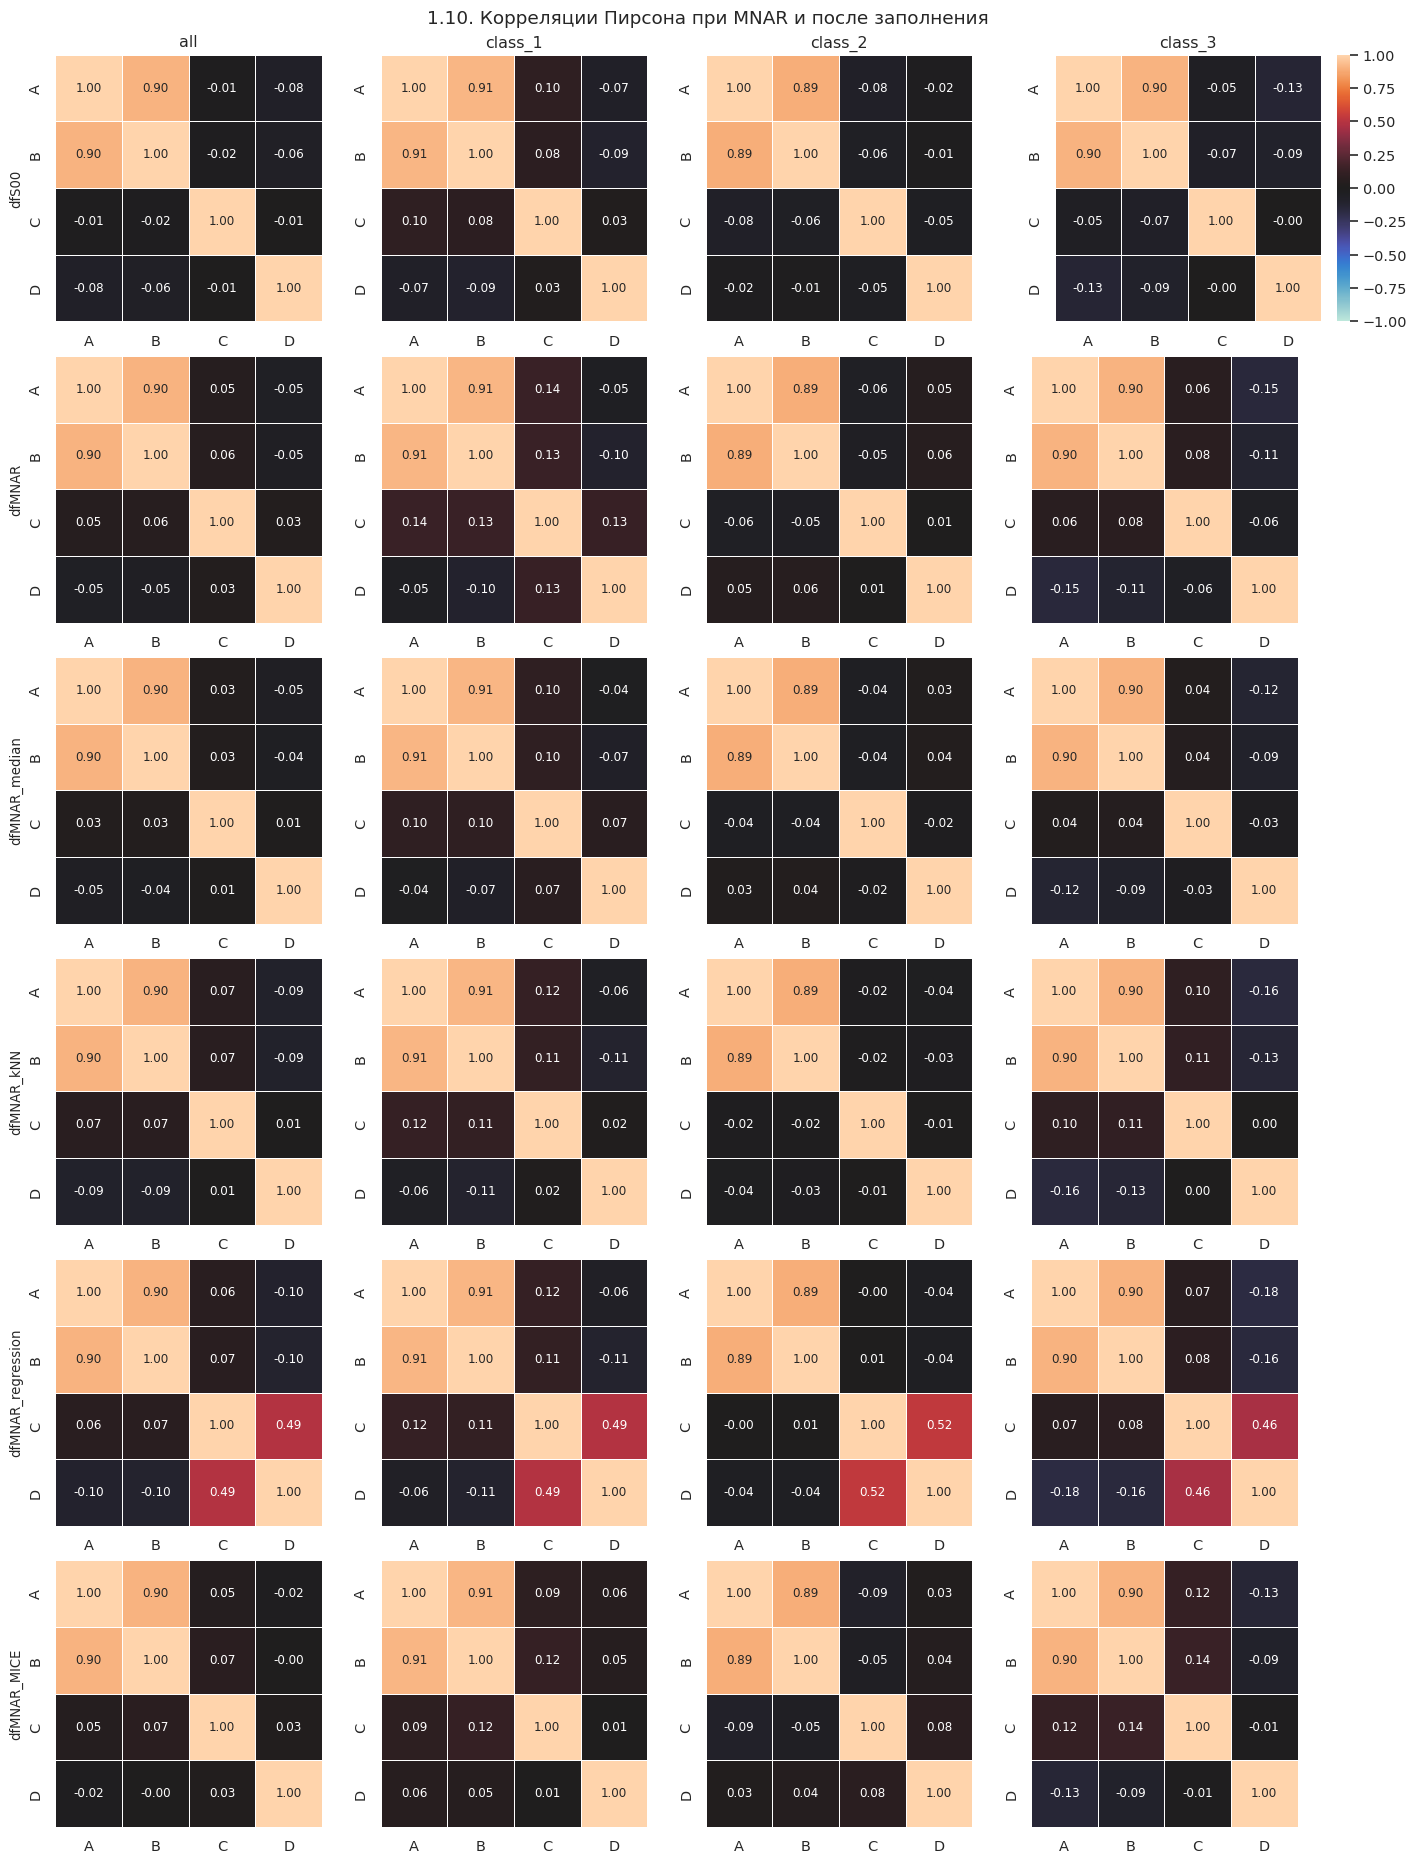

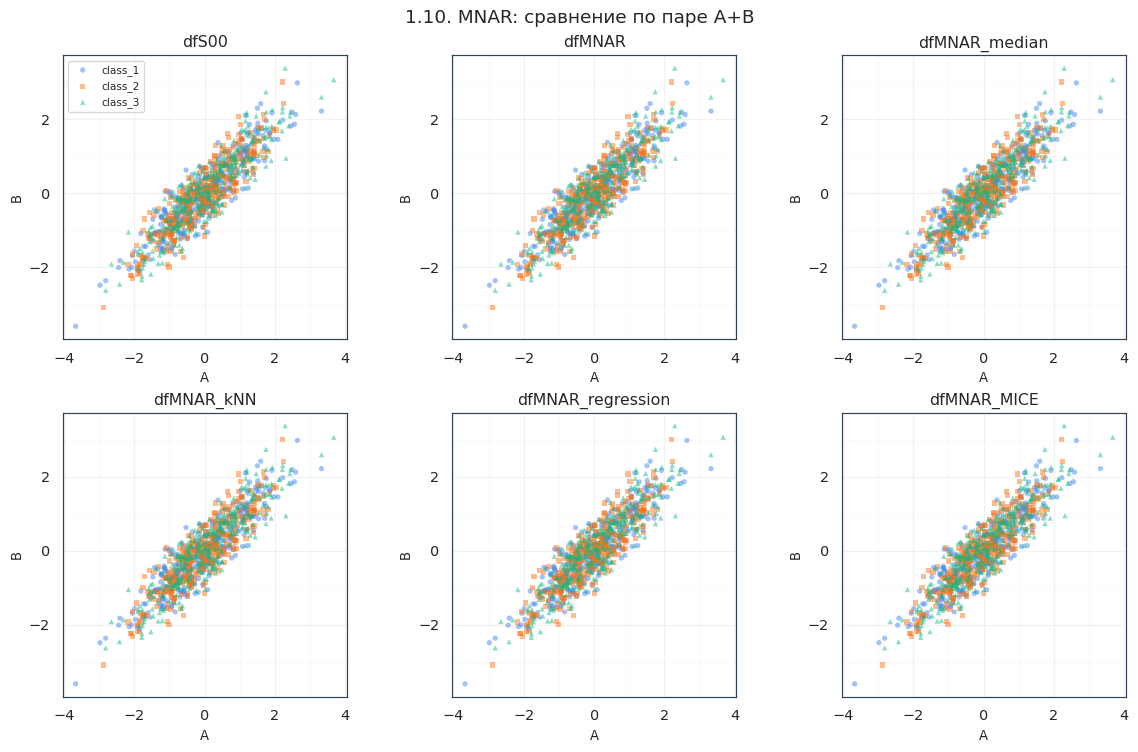

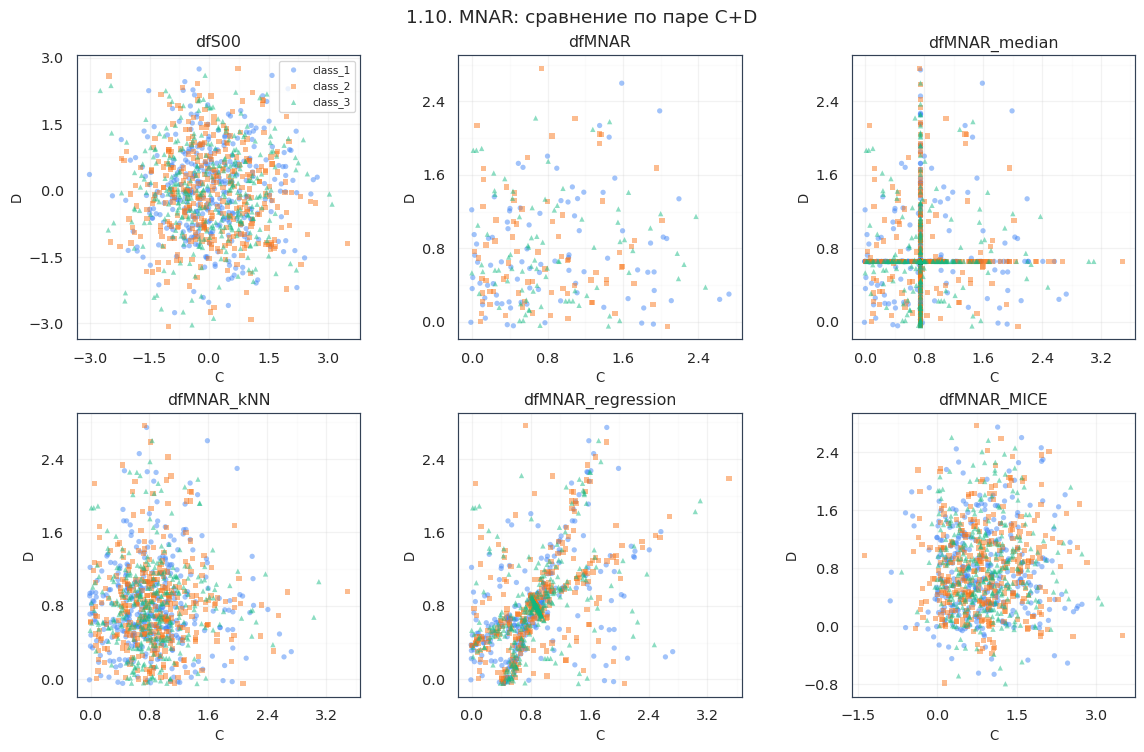

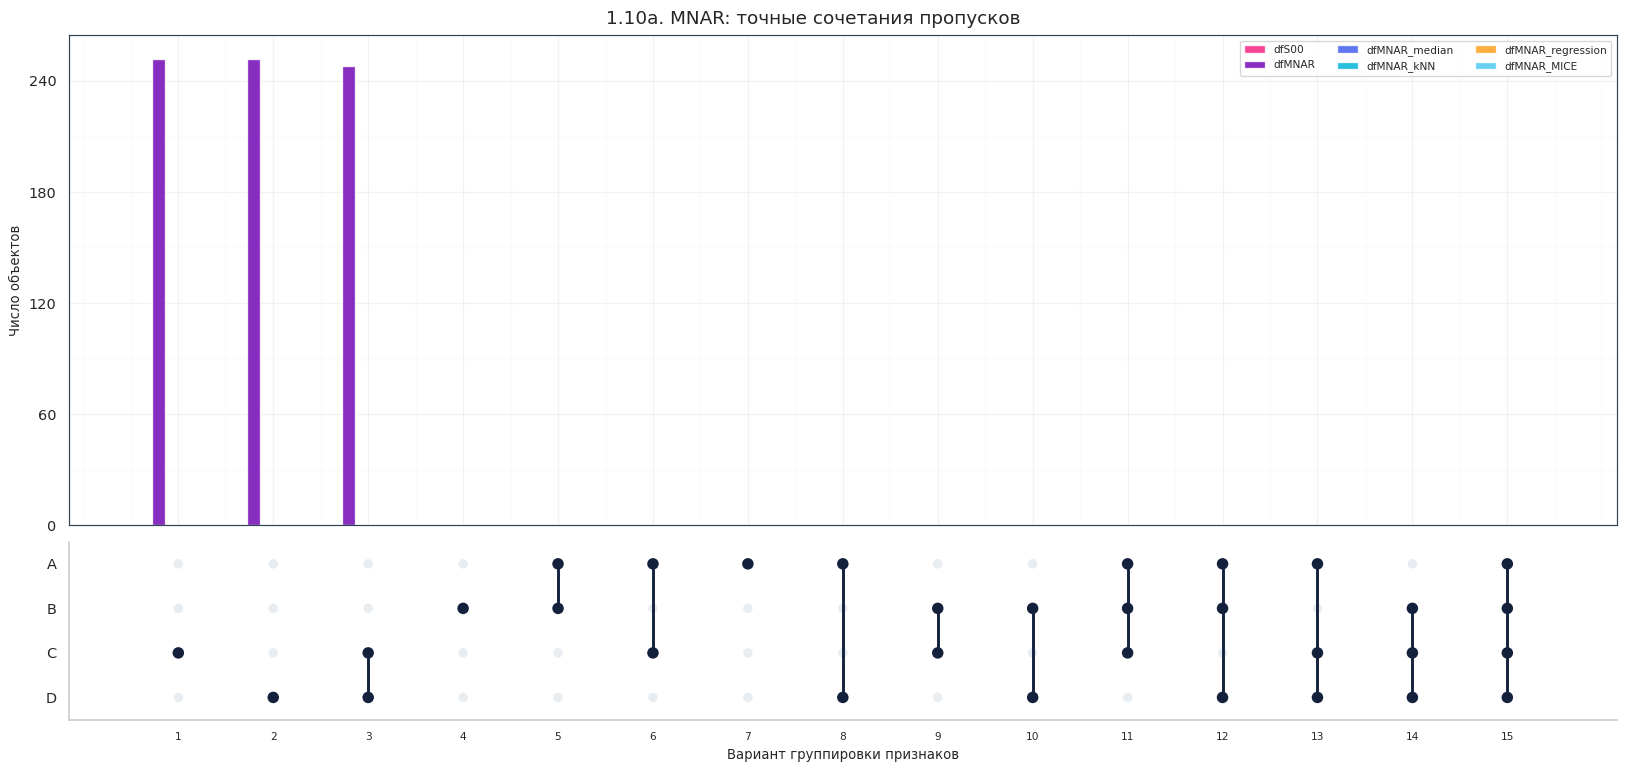

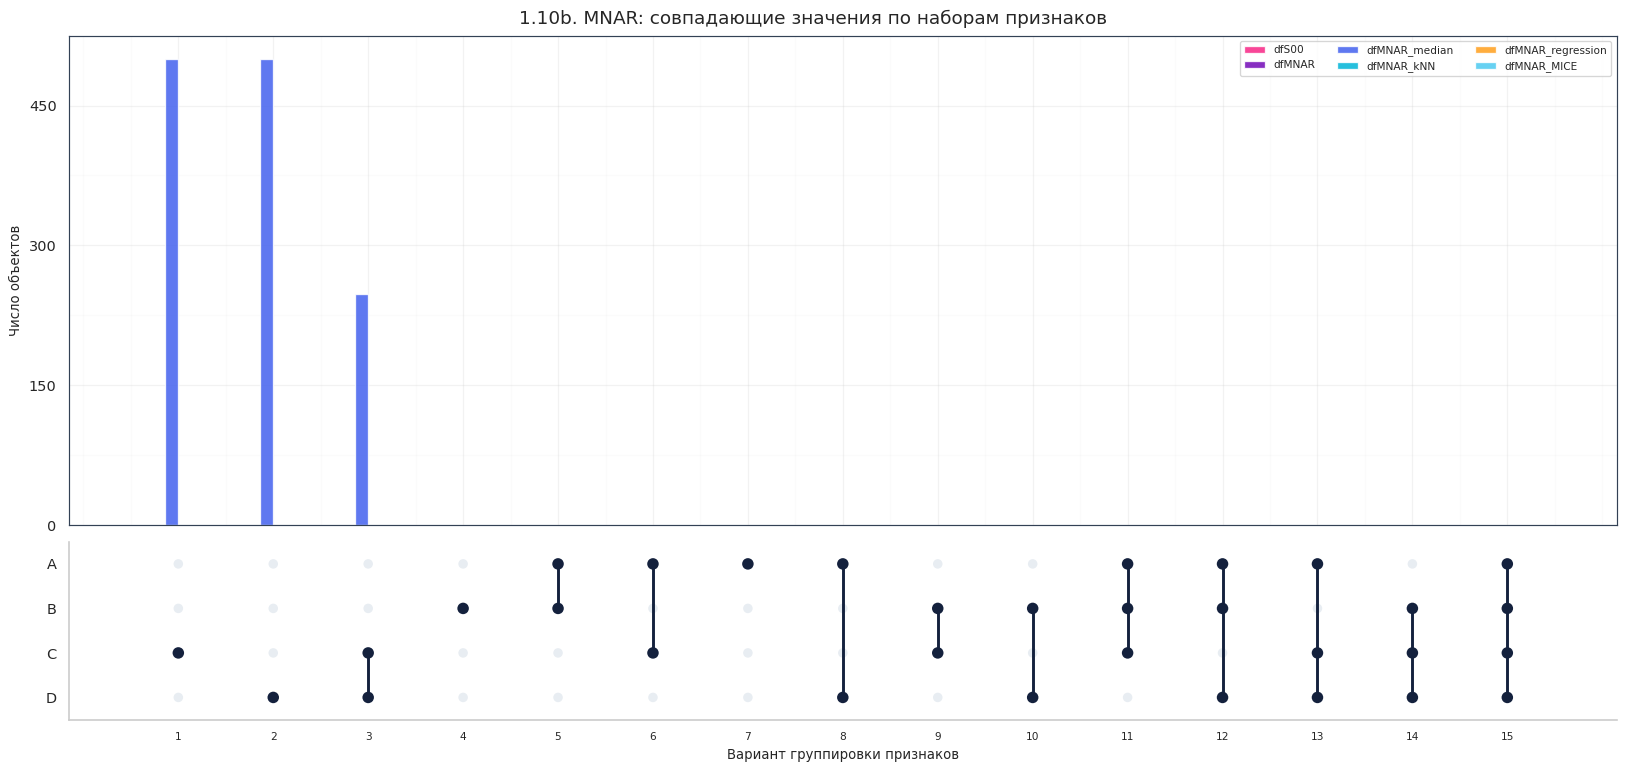

In [12]:
def make_mnar(frame):
    result = frame.copy(deep=True)
    thresholds = {}
    for feature in ("C", "D"):
        thresholds[feature] = frame[feature].median()
        result.loc[result[feature] < thresholds[feature], feature] = np.nan
    return result, thresholds


dfMNAR, mnar_thresholds = make_mnar(dfS00)
mnar_imputed = build_imputations(dfMNAR, seed=SEED + 1)
mnar_comparison = {
    "dfS00": dfS00,
    "dfMNAR": dfMNAR,
    **{f"dfMNAR_{name}": frame for name, frame in mnar_imputed.items()},
}

display(pd.DataFrame({
    "median_threshold": mnar_thresholds,
    "missing_after_MNAR": dfMNAR[["C", "D"]].isna().sum(),
}).round(4))

correlation_atlas(
    mnar_comparison,
    method="pearson",
    title="1.10. Корреляции Пирсона при MNAR и после заполнения",
)
scatter_panel(mnar_comparison, PAIR_1, "1.10. MNAR: сравнение по паре A+B", ncols=3)
scatter_panel(mnar_comparison, PAIR_2, "1.10. MNAR: сравнение по паре C+D", ncols=3)

mnar_missing_upset = upset_comparison(
    mnar_comparison,
    exact_missing_counts,
    "1.10a. MNAR: точные сочетания пропусков",
)
mnar_duplicate_upset = upset_comparison(
    mnar_comparison,
    duplicate_subset_counts,
    "1.10b. MNAR: совпадающие значения по наборам признаков",
)

## Итоговое количественное сравнение

Последняя таблица показывает абсолютную ошибку восстановленной корреляции относительно исходного `dfS00`. Чем меньше значение, тем лучше метод сохранил корреляционную структуру.

In [17]:
def correlation_error(reference, candidate):
    reference_corr = reference[FEATURES].corr("pearson")
    candidate_corr = candidate[FEATURES].corr("pearson")
    mask = np.triu(np.ones(reference_corr.shape, dtype=bool), k=1)
    delta = (candidate_corr - reference_corr).to_numpy()[mask]
    return {
        "MAE_all_pairs": np.abs(delta).mean(),
        "error_AB": abs(
            candidate_corr.loc["A", "B"] - reference_corr.loc["A", "B"]
        ),
        "corr_AB": candidate_corr.loc["A", "B"],
        "corr_CD": candidate_corr.loc["C", "D"],
    }


quality_rows = []
for mechanism, datasets in [
    ("MCAR 20%", comparison),
    ("MNAR", mnar_comparison),
]:
    for name, frame in datasets.items():
        row = {"mechanism": mechanism, "dataset": name}
        row.update(correlation_error(dfS00, frame))
        quality_rows.append(row)

quality = pd.DataFrame(quality_rows).sort_values(
    ["mechanism", "MAE_all_pairs"]
)
display(quality.round(4).style.hide(axis="index"))

print(
    "Выборочная корреляция A+B близка к заданным 0.9. "
    "При MCAR сильное удаление ячеек увеличивает разброс оценки; "
    "медианная импутация обычно ослабляет связь, а многомерные методы "
    "лучше используют взаимосвязь признаков. При MNAR ни один простой "
    "метод не гарантирует устранения смещения, потому что механизм "
    "пропусков зависит от самих скрытых значений."
)

mechanism,dataset,MAE_all_pairs,error_AB,corr_AB,corr_CD
MCAR 20%,dfSd00,0.000000,0.000000,0.902000,-0.007400
MCAR 20%,dfSd20_MICE,0.011600,0.002700,0.899300,-0.031300
MCAR 20%,dfSd20_regression,0.015500,0.025100,0.927100,-0.038200
MCAR 20%,dfSd20,0.016800,0.008100,0.894000,-0.029700
MCAR 20%,dfSd20_kNN,0.024300,0.115500,0.786600,-0.006300
MCAR 20%,dfSd20_median,0.043100,0.191400,0.710600,-0.022500
MNAR,dfS00,0.000000,0.000000,0.902000,-0.007400
MNAR,dfMNAR_median,0.026400,0.000000,0.902000,0.008700
MNAR,dfMNAR,0.034500,0.000000,0.902000,0.032700
MNAR,dfMNAR_kNN,0.036200,0.000000,0.902000,0.006500


Выборочная корреляция A+B близка к заданным 0.9. При MCAR сильное удаление ячеек увеличивает разброс оценки; медианная импутация обычно ослабляет связь, а многомерные методы лучше используют взаимосвязь признаков. При MNAR ни один простой метод не гарантирует устранения смещения, потому что механизм пропусков зависит от самих скрытых значений.
